# Model Selection: Choosing the Right Algorithm

---

## The Central Question

You've learned several algorithms: logistic regression, decision trees, SVMs, random forests, neural networks. Now comes the practical question: which one should you use for your problem?

The answer isn't just "whichever fits training data best." A model that memorizes training examples perfectly might fail catastrophically on new data. What we actually care about is **generalization:** how well the model performs on data it hasn't seen.

This notebook covers the standard techniques for estimating generalization performance and selecting models:

1. **Train/Test Split** the simplest approach
2. **Cross-Validation** more robust estimation
3. **Three-Way Split** the gold standard for final selection
4. **Learning Curves** diagnosing model behavior

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, classification_report
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

## 1. Train/Test Split

The simplest way to estimate generalization: partition your data into two disjoint sets.

- **Training set**: fit your model
- **Test set**: evaluate performance (data the model never saw during training)

### Why Not Just Evaluate on Training Data?

Training error is deceptively optimistic. A sufficiently complex model can achieve near-zero training error by memorizing examples but this tells us nothing about how it will handle new inputs. The test set acts as a proxy for "future data" we'll encounter in deployment.

Training set size: 800 samples
Test set size: 200 samples
Number of features: 20


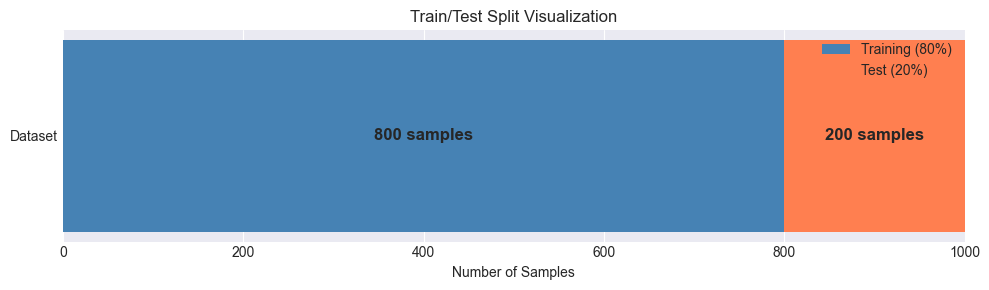

In [2]:
# Generate a classification dataset
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15, 
                          n_redundant=5, random_state=42)

# Split into train and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

# Visualize the split
fig, ax = plt.subplots(figsize=(10, 3))
train_bar = ax.barh(['Dataset'], [len(X_train)], color='steelblue', label='Training (80%)')
test_bar = ax.barh(['Dataset'], [len(X_test)], left=[len(X_train)], 
                   color='coral', label='Test (20%)')
ax.set_xlabel('Number of Samples')
ax.set_title('Train/Test Split Visualization')
ax.legend()
ax.set_xlim(0, len(X))

# Add text annotations
ax.text(len(X_train)/2, 0, f'{len(X_train)} samples', 
       ha='center', va='center', fontsize=12, fontweight='bold')
ax.text(len(X_train) + len(X_test)/2, 0, f'{len(X_test)} samples', 
       ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Comparing Models with Train/Test Split

Let's train several classifiers and compare their generalization performance:

In [3]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate each model
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Evaluate
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Difference': train_acc - test_acc
    })

# Create results dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("\nModel Comparison Results:")
print("=" * 80)
print(results_df.to_string(index=False))
print("\nNote: Large 'Difference' values may indicate overfitting")


Model Comparison Results:
              Model  Train Accuracy  Test Accuracy  Difference
                SVM          0.9700          0.935      0.0350
K-Nearest Neighbors          0.9575          0.900      0.0575
      Random Forest          1.0000          0.900      0.1000
Logistic Regression          0.8150          0.825     -0.0100
      Decision Tree          1.0000          0.790      0.2100

Note: Large 'Difference' values may indicate overfitting


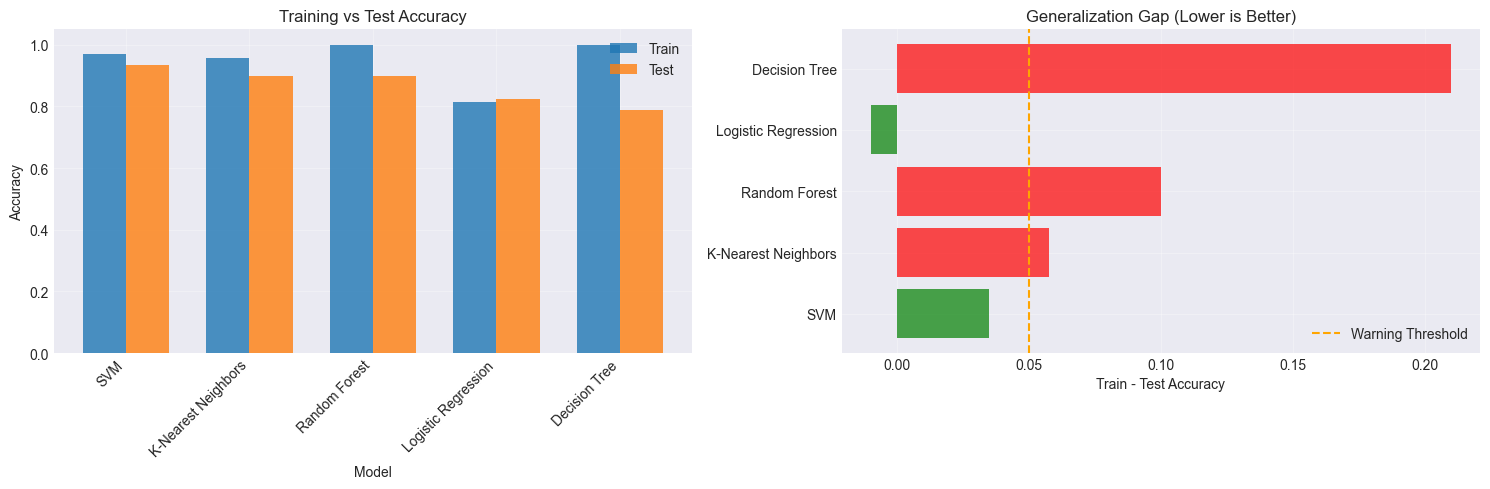

In [4]:
# Visualize results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Training vs Test Accuracy
x = np.arange(len(results_df))
width = 0.35

ax1.bar(x - width/2, results_df['Train Accuracy'], width, label='Train', alpha=0.8)
ax1.bar(x + width/2, results_df['Test Accuracy'], width, label='Test', alpha=0.8)
ax1.set_xlabel('Model')
ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Test Accuracy')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Generalization Gap
colors = ['red' if diff > 0.05 else 'green' for diff in results_df['Difference']]
ax2.barh(results_df['Model'], results_df['Difference'], color=colors, alpha=0.7)
ax2.set_xlabel('Train - Test Accuracy')
ax2.set_title('Generalization Gap (Lower is Better)')
ax2.axvline(x=0.05, color='orange', linestyle='--', label='Warning Threshold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Limitations of a Single Split

A single train/test split has drawbacks:

| Issue | Description |
|-------|-------------|
| **High variance** | Results depend heavily on which samples land in train vs test |
| **Wasted data** | Test samples can't be used for training |
| **No tuning separation** | If we tune hyperparameters on test set, it's no longer unbiased |

For small datasets especially, a single split can give misleading estimates. Cross-validation addresses this.

## 2. K-Fold Cross-Validation

Cross-validation provides a more robust estimate by using **all** data for both training and testing (just not simultaneously).

### How It Works

1. Partition data into $K$ equal-sized "folds"
2. For each fold $i = 1, \ldots, K$:
   - Train on all folds except fold $i$
   - Evaluate on fold $i$
3. Average the $K$ evaluation scores

Every sample gets used for testing exactly once, and for training $K-1$ times. Common choices: $K=5$ or $K=10$.

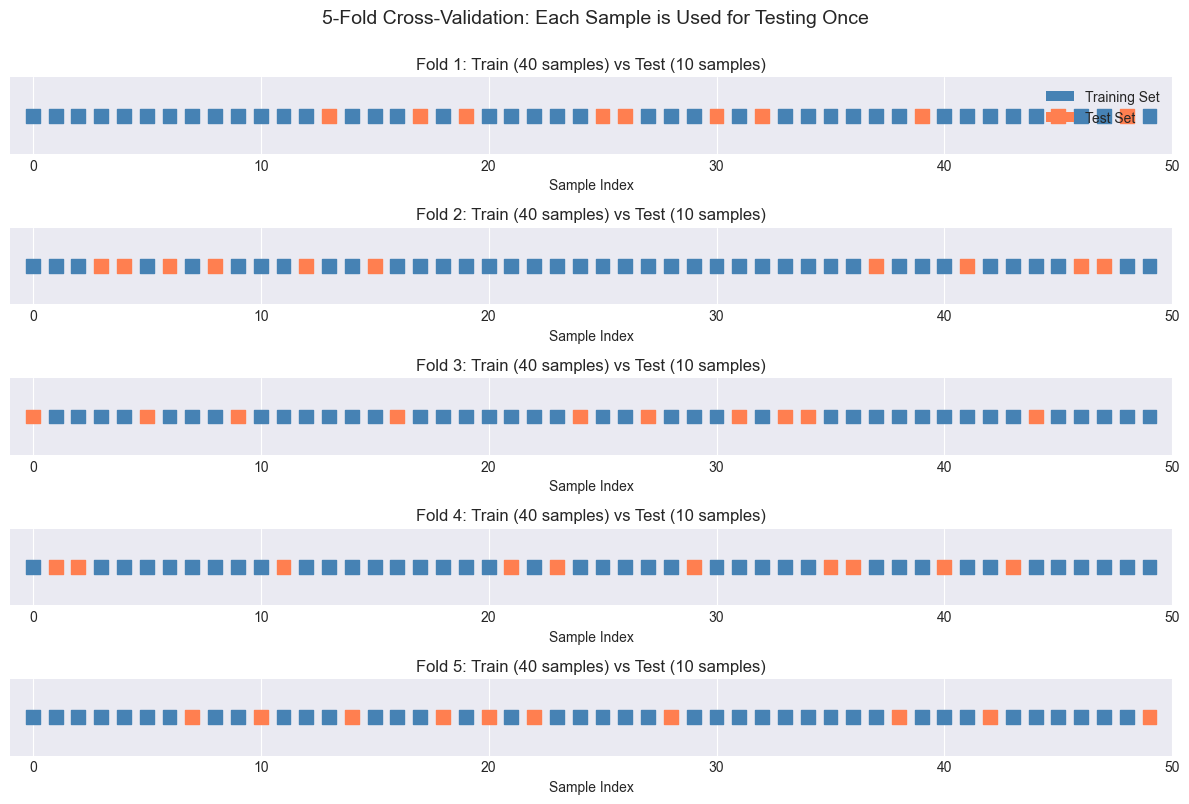

In [5]:
# Visualize K-Fold Cross-Validation
fig, axes = plt.subplots(5, 1, figsize=(12, 8))
n_samples = 50
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for idx, (train_idx, test_idx) in enumerate(kfold.split(range(n_samples))):
    ax = axes[idx]
    
    # Create visualization array
    colors = np.array(['steelblue'] * n_samples)
    colors[test_idx] = 'coral'
    
    # Plot
    ax.scatter(range(n_samples), [0]*n_samples, c=colors, s=100, marker='s')
    ax.set_yticks([])
    ax.set_xlim(-1, n_samples)
    ax.set_title(f'Fold {idx + 1}: Train ({len(train_idx)} samples) vs Test ({len(test_idx)} samples)')
    ax.set_xlabel('Sample Index')
    
    if idx == 0:
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='steelblue', label='Training Set'),
            Patch(facecolor='coral', label='Test Set')
        ]
        ax.legend(handles=legend_elements, loc='upper right')

plt.suptitle('5-Fold Cross-Validation: Each Sample is Used for Testing Once', 
            fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

### Comparing Models with Cross-Validation

Cross-validation gives us not just a point estimate, but a distribution of scores, the standard deviation indicates how stable the model's performance is across different data subsets.

In [6]:
# Use full dataset (no train/test split needed for CV)
cv_results = []

# Perform 5-fold cross-validation for each model
for name, model in models.items():
    # Perform cross-validation
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    
    cv_results.append({
        'Model': name,
        'Mean CV Accuracy': scores.mean(),
        'Std CV Accuracy': scores.std(),
        'Min': scores.min(),
        'Max': scores.max()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values('Mean CV Accuracy', ascending=False)

print("\n5-Fold Cross-Validation Results:")
print("=" * 95)
print(cv_results_df.to_string(index=False))
print("\nNote: Standard deviation shows consistency across folds")


5-Fold Cross-Validation Results:
              Model  Mean CV Accuracy  Std CV Accuracy   Min   Max
                SVM             0.941         0.020100 0.920 0.970
K-Nearest Neighbors             0.927         0.013266 0.910 0.950
      Random Forest             0.916         0.016553 0.900 0.945
Logistic Regression             0.811         0.016248 0.780 0.825
      Decision Tree             0.785         0.024698 0.755 0.825

Note: Standard deviation shows consistency across folds


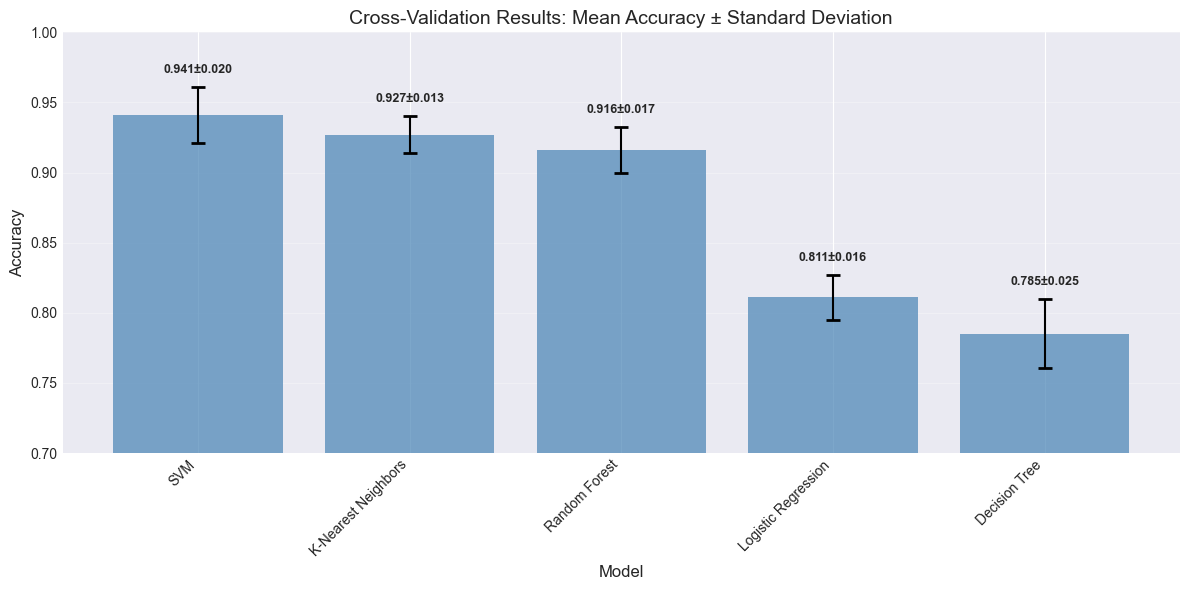

In [7]:
# Visualize cross-validation results
fig, ax = plt.subplots(figsize=(12, 6))

# Plot mean accuracy with error bars
x = np.arange(len(cv_results_df))
ax.bar(x, cv_results_df['Mean CV Accuracy'], alpha=0.7, color='steelblue')
ax.errorbar(x, cv_results_df['Mean CV Accuracy'], 
           yerr=cv_results_df['Std CV Accuracy'],
           fmt='none', ecolor='black', capsize=5, capthick=2)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_results_df['Mean CV Accuracy'], 
                                     cv_results_df['Std CV Accuracy'])):
    ax.text(i, mean + std + 0.01, f'{mean:.3f}±{std:.3f}', 
           ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Cross-Validation Results: Mean Accuracy ± Standard Deviation', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(cv_results_df['Model'], rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.7, 1.0)

plt.tight_layout()
plt.show()

### Variants of Cross-Validation

| Method | Description | When to Use |
|--------|-------------|-------------|
| **K-Fold** | Standard approach (K=5 or 10) | General purpose |
| **Stratified K-Fold** | Preserves class proportions in each fold | Classification with imbalanced classes |
| **Leave-One-Out (LOO)** | K = n (each sample is its own fold) | Very small datasets |
| **Repeated K-Fold** | Run K-fold multiple times with different splits | When variance of estimate matters |
| **Time Series Split** | Folds respect temporal order | Time series data |

**Trade-off**: More folds → less bias but more computation. LOO uses all data maximally but requires $n$ model fits.

## 3. Learning Curves: Diagnosing Model Behavior

Learning curves plot model performance as a function of training set size. They help answer:

- **Would more data help?** If validation score is still improving, yes.
- **Is the model overfitting?** Large gap between training and validation curves.
- **Is the model underfitting?** Both curves plateau at low performance.

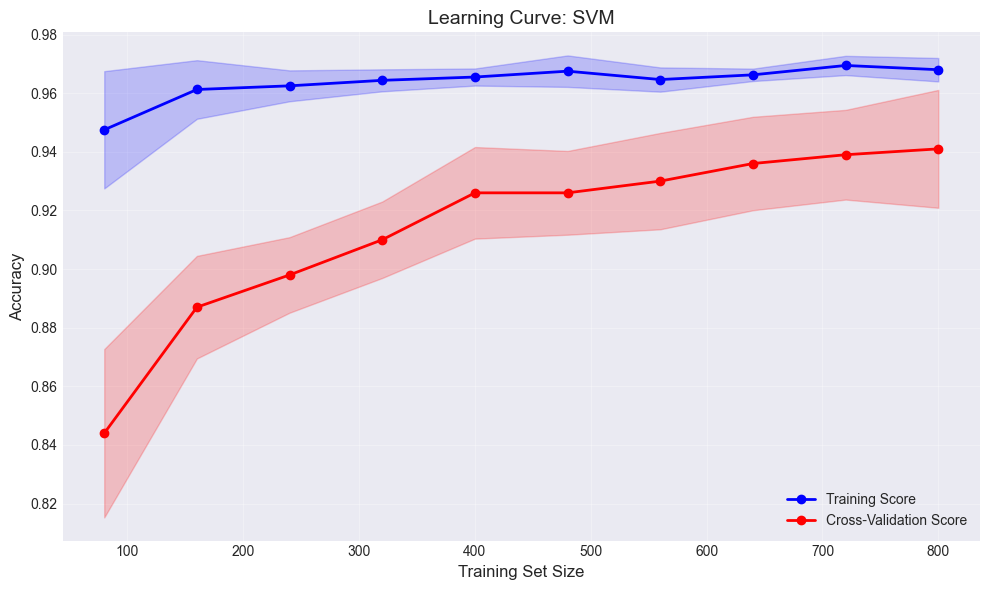


Learning Curve Interpretation:
 Good balance between training and CV performance

 CV score has plateaued
   More training data likely won't help much


In [9]:
# Select best model from CV
best_model_name = cv_results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Generate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X, y, 
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

# Calculate mean and std
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
test_mean = test_scores.mean(axis=1)
test_std = test_scores.std(axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                alpha=0.2, color='blue')

plt.plot(train_sizes, test_mean, 'o-', color='red', label='Cross-Validation Score', linewidth=2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, 
                alpha=0.2, color='red')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title(f'Learning Curve: {best_model_name}', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nLearning Curve Interpretation:")
gap = train_mean[-1] - test_mean[-1]
if gap > 0.1:
    print(" Large gap between training and CV scores suggests overfitting")
    print("  Consider: regularization, simpler model, or more data")
elif test_mean[-1] < 0.7:
    print(" Low overall performance suggests underfitting")
    print("  Consider: more complex model or better features")
else:
    print(" Good balance between training and CV performance")

# Check if more data would help
if test_mean[-1] - test_mean[-2] > 0.01:
    print("\nCV score still improving with more data")
    print(" More training data might improve performance further")
else:
    print("\nCV score has plateaued")
    print(" More training data likely won't help much")

## 4. The Three-Way Split: Production Workflow

For serious model development, cross-validation alone isn't enough. The problem: if you repeatedly evaluate different models on your CV folds and pick the best one, you're implicitly "training" on that evaluation data.

### The Solution: Hold Out a Final Test Set

| Split | Purpose | When to Use |
|-------|---------|-------------|
| **Training** (~60-70%) | Fit model parameters | During training |
| **Validation** (~15-20%) | Model selection, hyperparameter tuning | During development |
| **Test** (~15-20%) | Final unbiased evaluation | Once, at the very end |

**Golden Rule**: Never touch the test set until you've made all modeling decisions. It should simulate "deployment" data you'll see only once in production.

Three-Way Split:
  Training: 640 samples (64.0%)
  Validation: 160 samples (16.0%)
  Test: 200 samples (20.0%)


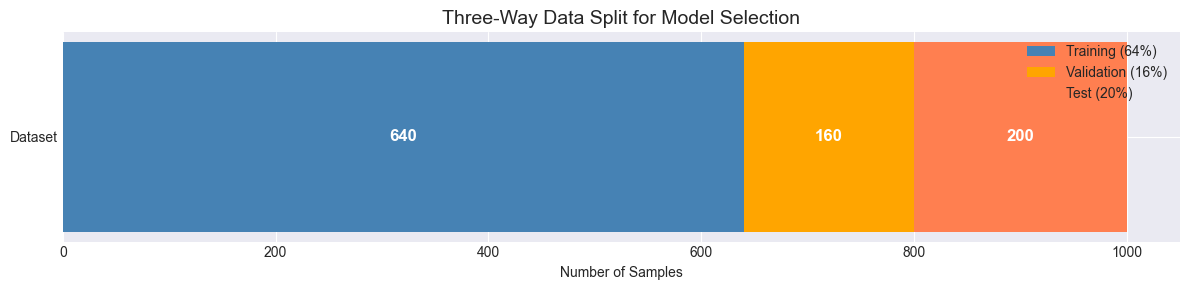

In [10]:
# Demonstrate three-way split
X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print("Three-Way Split:")
print(f"  Training: {len(X_train_final)} samples ({len(X_train_final)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test: {len(X_test_final)} samples ({len(X_test_final)/len(X)*100:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(12, 3))
ax.barh(['Dataset'], [len(X_train_final)], color='steelblue', label='Training (64%)')
ax.barh(['Dataset'], [len(X_val)], left=[len(X_train_final)], 
       color='orange', label='Validation (16%)')
ax.barh(['Dataset'], [len(X_test_final)], 
       left=[len(X_train_final) + len(X_val)], 
       color='coral', label='Test (20%)')

ax.set_xlabel('Number of Samples')
ax.set_title('Three-Way Data Split for Model Selection', fontsize=14)
ax.legend()

# Add annotations
positions = [len(X_train_final)/2, 
            len(X_train_final) + len(X_val)/2,
            len(X_train_final) + len(X_val) + len(X_test_final)/2]
labels = [f'{len(X_train_final)}', f'{len(X_val)}', f'{len(X_test_final)}']

for pos, label in zip(positions, labels):
    ax.text(pos, 0, label, ha='center', va='center', 
           fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

### Complete Model Selection Workflow

In [11]:
# Step 1: Train multiple models on training set
print("Step 1: Training candidate models...\n")
candidate_models = {}
validation_scores = {}

for name, model in models.items():
    model.fit(X_train_final, y_train_final)
    val_pred = model.predict(X_val)
    val_score = accuracy_score(y_val, val_pred)
    
    candidate_models[name] = model
    validation_scores[name] = val_score
    print(f"{name:25s} Validation Accuracy: {val_score:.4f}")

# Step 2: Select best model based on validation performance
best_model_final = max(validation_scores, key=validation_scores.get)
print(f"\nStep 2: Selected model: {best_model_final}")
print(f"         Validation accuracy: {validation_scores[best_model_final]:.4f}")

# Step 3: Final evaluation on test set (only done once!)
print("\nStep 3: Final evaluation on held-out test set...")
final_model = candidate_models[best_model_final]
test_pred = final_model.predict(X_test_final)
test_score = accuracy_score(y_test_final, test_pred)

print(f"\n{'='*60}")
print(f"FINAL TEST ACCURACY: {test_score:.4f}")
print(f"{'='*60}")

print("\nClassification Report on Test Set:")
print(classification_report(y_test_final, test_pred))

Step 1: Training candidate models...

Logistic Regression       Validation Accuracy: 0.7750
Decision Tree             Validation Accuracy: 0.8187
Random Forest             Validation Accuracy: 0.8938
SVM                       Validation Accuracy: 0.9313
K-Nearest Neighbors       Validation Accuracy: 0.9250

Step 2: Selected model: SVM
         Validation accuracy: 0.9313

Step 3: Final evaluation on held-out test set...

FINAL TEST ACCURACY: 0.9400

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       106
           1       0.91      0.97      0.94        94

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200



## 5. Common Pitfalls

### Data Leakage

Information from the test set "leaking" into training, leading to overoptimistic estimates.

**Examples:**
- Normalizing features using statistics computed on the full dataset (including test)
- Feature selection based on correlation with target across all data
- Time series: using future data to predict the past

**Prevention:** All preprocessing (scaling, imputation, feature selection) must be fit only on training data.

### Overfitting to the Validation Set

If you evaluate hundreds of model configurations on the validation set, you'll eventually find one that does well by chance. This is why the final test set must remain untouched.

### Ignoring Class Imbalance

Accuracy can be misleading when classes are imbalanced. A model predicting the majority class always achieves high accuracy but is useless. Use stratified splits and appropriate metrics (F1, AUC-ROC).

### Computational Costs

Some models are orders of magnitude slower to train than others. For large-scale model selection, consider:
- Starting with faster models as baselines
- Using smaller CV folds (K=3) for initial screening
- Parallelizing CV folds

## Summary

### Method Comparison

| Method | Pros | Cons | Best For |
|--------|------|------|----------|
| **Train/Test Split** | Simple, fast | High variance, wastes data | Quick experiments, large datasets |
| **K-Fold CV** | Uses all data, reliable estimates | Computationally expensive | Standard practice |
| **Three-Way Split** | Unbiased final evaluation | Reduces training data | Production systems |

### Key Principles

1. **Never evaluate on training data alone** it gives misleading optimism

2. **Cross-validation** is more reliable than single splits

3. **Preserve a final test set** touch it only once for unbiased evaluation

4. **Use learning curves** diagnose whether more data or model changes would help

5. **Watch for data leakage** all preprocessing must respect train/test boundaries

6. **Consider the full picture** accuracy isn't everything (speed, interpretability, fairness)